# Q3.1: 2D Manifold (Latent Mapping)
Train a symmetric MNIST Autoencoder with N=2 , then visualize the test set latent space as a scatter plot colored by digit label.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: cuda


In [5]:
# Symmetric AE: 784->128->64->2->64->128->784
class MNISTAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(784, 128), nn.ReLU(),
            nn.Linear(128, 64),  nn.ReLU(),
            nn.Linear(64, 2)
        )
        self.decoder = nn.Sequential(
            nn.Linear(2, 64),   nn.ReLU(),
            nn.Linear(64, 128), nn.ReLU(),
            nn.Linear(128, 784), nn.Sigmoid()
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))

# Data
transform = transforms.ToTensor()
train_data = MNIST(root='../../../datasets', train=True,  download=True, transform=transform)
test_data  = MNIST(root='../../../datasets', train=False, download=True, transform=transform)
train_loader = DataLoader(train_data, batch_size=256, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=256, shuffle=False)

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:04<00:00, 2.12MB/s]


Extracting ../../../datasets\MNIST\raw\train-images-idx3-ubyte.gz to ../../../datasets\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 124kB/s]


Extracting ../../../datasets\MNIST\raw\train-labels-idx1-ubyte.gz to ../../../datasets\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:02<00:00, 807kB/s]


Extracting ../../../datasets\MNIST\raw\t10k-images-idx3-ubyte.gz to ../../../datasets\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<?, ?B/s]

Extracting ../../../datasets\MNIST\raw\t10k-labels-idx1-ubyte.gz to ../../../datasets\MNIST\raw



Epoch 5/30  Loss: 0.04584
Epoch 10/30  Loss: 0.04171
Epoch 15/30  Loss: 0.04000
Epoch 20/30  Loss: 0.03893
Epoch 25/30  Loss: 0.03815
Epoch 30/30  Loss: 0.03760


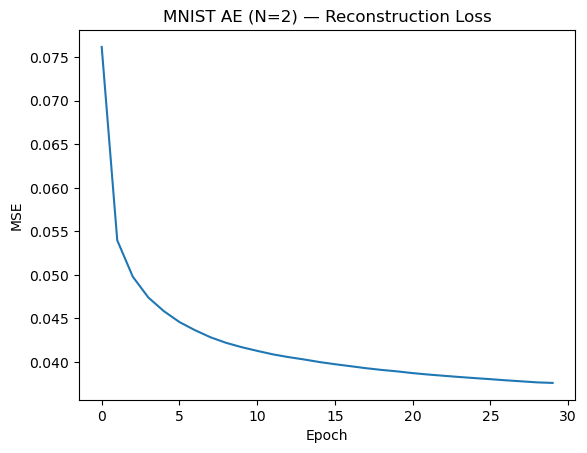

In [6]:
# Train
model = MNISTAutoencoder().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

losses = []
for epoch in range(30):
    epoch_loss = 0
    for imgs, _ in train_loader:
        x = imgs.view(-1, 784).to(device)
        loss = criterion(model(x), x)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * x.size(0)
    avg = epoch_loss / len(train_data)
    losses.append(avg)
    if (epoch+1) % 5 == 0: print(f'Epoch {epoch+1}/30  Loss: {avg:.5f}')

plt.plot(losses)
plt.title('MNIST AE (N=2) — Reconstruction Loss'); plt.xlabel('Epoch'); plt.ylabel('MSE')
plt.savefig('plots/q31_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

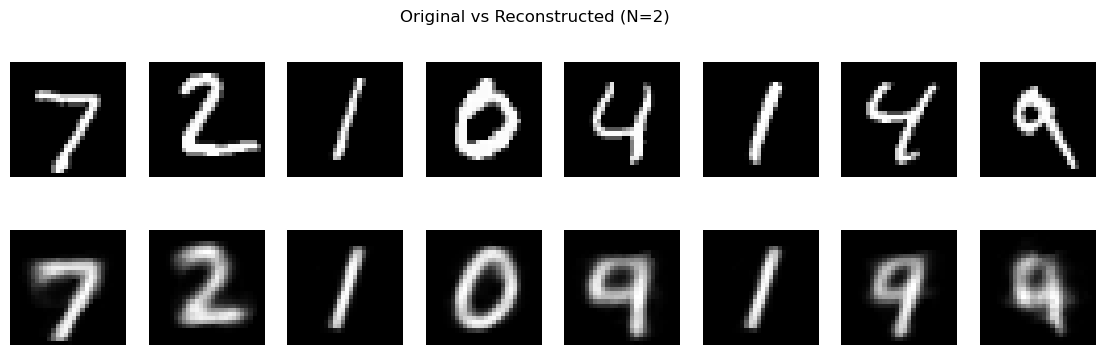

In [7]:
# Original vs Reconstructed
model.eval()
sample_imgs, _ = next(iter(test_loader))
x_sample = sample_imgs[:8].view(-1, 784).to(device)
with torch.no_grad():
    recon = model(x_sample).cpu().view(-1, 1, 28, 28)

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i in range(8):
    axes[0, i].imshow(sample_imgs[i].squeeze(), cmap='gray'); axes[0, i].axis('off')
    axes[1, i].imshow(recon[i].squeeze(), cmap='gray'); axes[1, i].axis('off')
axes[0, 0].set_ylabel('Original'); axes[1, 0].set_ylabel('Recon')
plt.suptitle('Original vs Reconstructed (N=2)')
plt.savefig('plots/q31_recon.png', dpi=150, bbox_inches='tight')
plt.show()

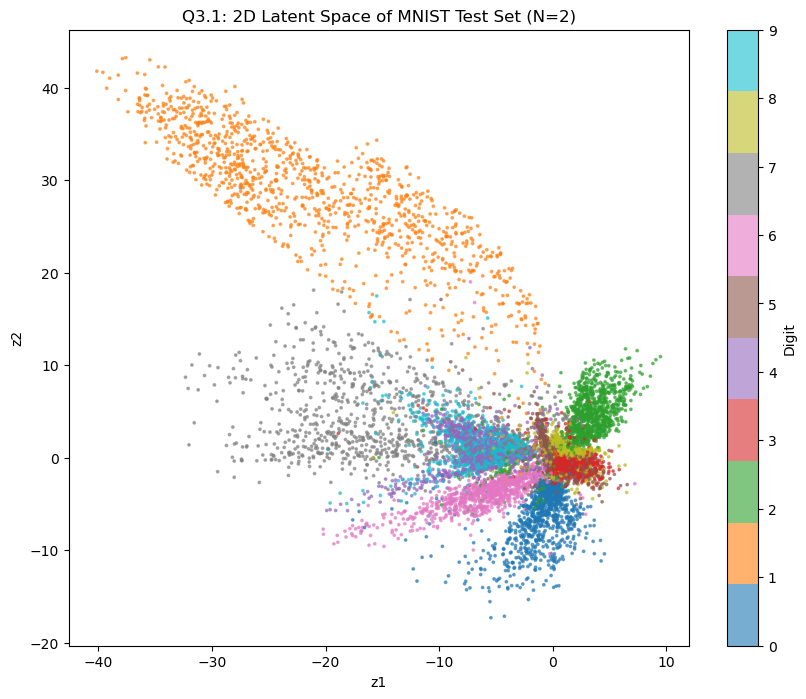

In [9]:
# 2D Latent Space Scatter Plot
all_z, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        z = model.encoder(imgs.view(-1, 784).to(device)).cpu().numpy()
        all_z.append(z); all_labels.append(labels.numpy())
all_z = np.concatenate(all_z); all_labels = np.concatenate(all_labels)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(all_z[:, 0], all_z[:, 1], c=all_labels, cmap='tab10', s=3, alpha=0.6)
plt.colorbar(scatter, ticks=range(10), label='Digit')
plt.title('Q3.1: 2D Latent Space of MNIST Test Set (N=2)')
plt.xlabel('z1'); plt.ylabel('z2')
plt.savefig('plots/q31_latent_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
